<a href="https://colab.research.google.com/github/zeferinopanyvino/breastcancer_classifier/blob/main/Breastcancer_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Clasificador de cáncer de mama
En este notebook queremos explorar 3 tipos de algoritmos de ML con sus regularizaciones para poner en práctica los conceptos vistos durante el primer módulo de curso *Machine Learning and AI for the working Analyst* de Escuela de Matemáticas Bourbaki

Los modelos que usaremos serán:


*   Arboles de decisión y Random Forest Classifier
*   Perceptrón y SVM
*   Regresión logística y Ridge

Si como yo necesitas al principio un repaso de cáncer de mama, cuando un tumor es benigno o maligno, mira el pequeñísimo Breviario.

Mi código normalmente está en inglés y a veces intercalo con variables en español, gracias por la comprensión si se va algo.




Para los datos usamos: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data?select=data.csv

In [19]:
import kagglehub

path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
from scipy import stats
plt.style.use("ggplot")

In [71]:
# Herramientas para modelos de ML
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, accuracy_score,
                           precision_recall_curve, average_precision_score)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Perceptron, LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Para visualizar el árbol de decisión
import graphviz
#import dtreeviz


In [4]:
df = pd.read_csv("/kaggle/input/breast-cancer-wisconsin-data/data.csv")

##Lectura data

In [5]:
df.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN


Cantidad de imágenes: 569

In [6]:
df.shape[0]

569

#Explorando un poco los datos   
Prestaremos atención a si eliminamos algunos datos, como columnas con solo valores NaN como la ultima columna del dataset, y Id que no sirve para los propósitos de clasificación. A su vez, columna "diagnosis" es nuestra predicción de tejido cancerigeno maligno (Malignant) o benigno (Bening)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [32]:
df = df.drop(columns=["Unnamed: 32", "id"], axis=1)


KeyError: "['Unnamed: 32', 'id'] not found in axis"

De lo anterior vemos que todas las observaciones son flotantes, representando medidas de algun tipo sobre los tejidos, por tanto nos interesara saber dimensiones esos valores y saber si tendremos que normalizar o estandarizar los rangos de algunas caracteristicas.

In [27]:
df.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Cuántas tenemos cancerígenas y cuántas no

In [10]:
value_counts= df["diagnosis"].value_counts()
print(value_counts)

diagnosis
B    357
M    212
Name: count, dtype: int64


357 registros benignos y 212 diagnósticos de tumores malignos

In [11]:
y= df['diagnosis'] #Guardamos las etiquetas de las imagenes como serie de pandas y convertimos a numeros siendo
# "M"= 1, "B"=0
Y= df['diagnosis'] = df['diagnosis'].map({'M':1,'B':0})
df.head()
y

,diagnosis
0,1
1,1
2,1
3,1
4,1
...,...
564,1
565,1
566,1
567,1


##Breviario
Si como yo necesitas un repaso de lo que son tumores, malignos y benignos, cuándo son cancerigenos (típicamente Malign), cuándo no (típicamente benigno) y otros detalles más para el problema en cuestión, mira esta liga:
https://www.cancercenter.com/community/blog/2023/01/whats-the-difference-benign-vs-malignant-tumors

Más información sobre cáncer de mama (base de datos está en inglés breast cancer):
Qué es el cáncer de mama y cómo detectar (por organización mundial de la salud):
https://www.who.int/es/news-room/fact-sheets/detail/breast-cancer

#Analisis exploratorio de datos con histograma
Queremos ver algo mas de visualizacion de estos datos, veamos panorama en torno a radius_mean

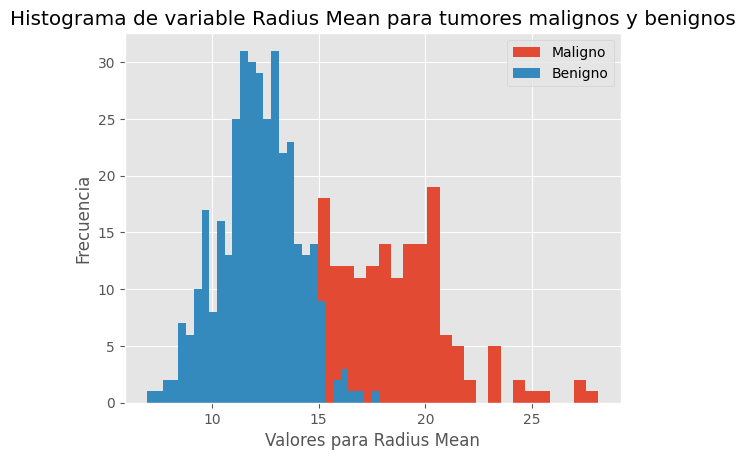

El radio promedio (Radius Mean) más frecuente es:  20.101999999999997


In [12]:
m = plt.hist(data[data["diagnosis"] == "M"].radius_mean,bins=30,fc = (1,0,0,0.2),label = "Maligno")
b = plt.hist(data[data["diagnosis"] == "B"].radius_mean,bins=30,fc = (0,.5,0,0.1),label = "Benigno")
plt.legend()
plt.xlabel("Valores para Radius Mean")
plt.ylabel("Frecuencia")
plt.title("Histograma de variable Radius Mean para tumores malignos y benignos")
plt.show()
# como m contiene el array de frecuencias para cada bin, agarramos la posicion de la frecuencia maxima
frequent_malignant_radius_mean = m[0].max()
index_frequent_malignant_radius_mean = list(m[0]).index(frequent_malignant_radius_mean)
most_frequent_malignant_radius_mean = m[1][index_frequent_malignant_radius_mean]
print("El radio promedio (Radius Mean) más frecuente es: ",most_frequent_malignant_radius_mean)

Es interesante observar que a ojo la distribución de tumores benignos sigue una normal.

A simple vista, el promedio de radios de benignos y malignos pareciera diferir por lo que podemos imaginar que, de hacer feature selection con árboles de decision y random forest probablemente esta característica sea una de las preguntas top en el árbol para la clasificación.

Se podria hacer análisis que permita identificar si 'radius_mean' es un buen predictor para distinguir entre tumores malignos y benignos basándose en la separación de sus distribuciones.


Consideramos que vale la pena visualizar histogramas de las columnas con _mean que brindan **promedios**.

In [13]:
features_mean=list(df.columns[1:11])
# split dataframe into two based on diagnosis
dfM=df[df['diagnosis'] ==1]
dfB=df[df['diagnosis'] ==0]

In [14]:
print((features_mean))

['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean']


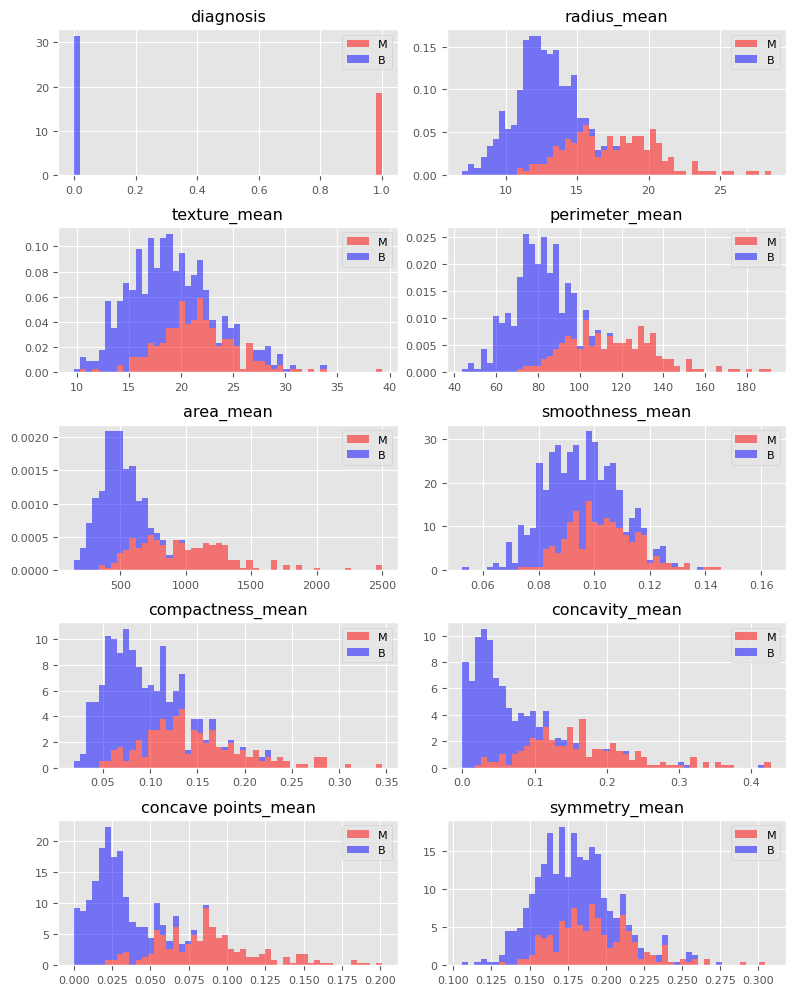

In [15]:
#haciendo histogramas para cada carateristica
# Configuración de visualización
plt.rcParams.update({'font.size': 8})  # Fuente pequeña para ajustar 10 gráficos
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(8,10))  # Cuadrícula 5x2
axes = axes.ravel();  # Aplanar para fácil iteración
# Cálculo dinámico de bins para cada característica
#binwidth - divide el rango de cada característica en 50 bins igualmente espaciados
# Creación de histogramas comparativos
for idx, ax in enumerate(axes):
        ax.figure
        binwidth= (max(df[features_mean[idx]]) - min(df[features_mean[idx]]))/50
        ax.hist([dfM[features_mean[idx]], dfB[features_mean[idx]]],
        bins=np.arange(min(df[features_mean[idx]]), max(df[features_mean[idx]]) + binwidth, binwidth),
        alpha=0.5,          # Transparencia para ver superposición
        stacked=True,       # Apila los histogramas
        density=True,        # Normaliza (área total = 1)
        label=['M', 'B'],
        color=['r', 'b'])   # red=Maligno, blue=Benigno
        ax.legend(loc='upper right')
        ax.set_title(features_mean[idx])
plt.tight_layout()
plt.show()

Observaciones:

caracteristicas: radius, perimeter, area, compactness, concavity and concave points prestan a decir cosas sobre la separabilidad de las predicciones, lo tendremos en cuenta ya que tengamos feature selection con arboles de decision y random forest.

Matriz de correlación:


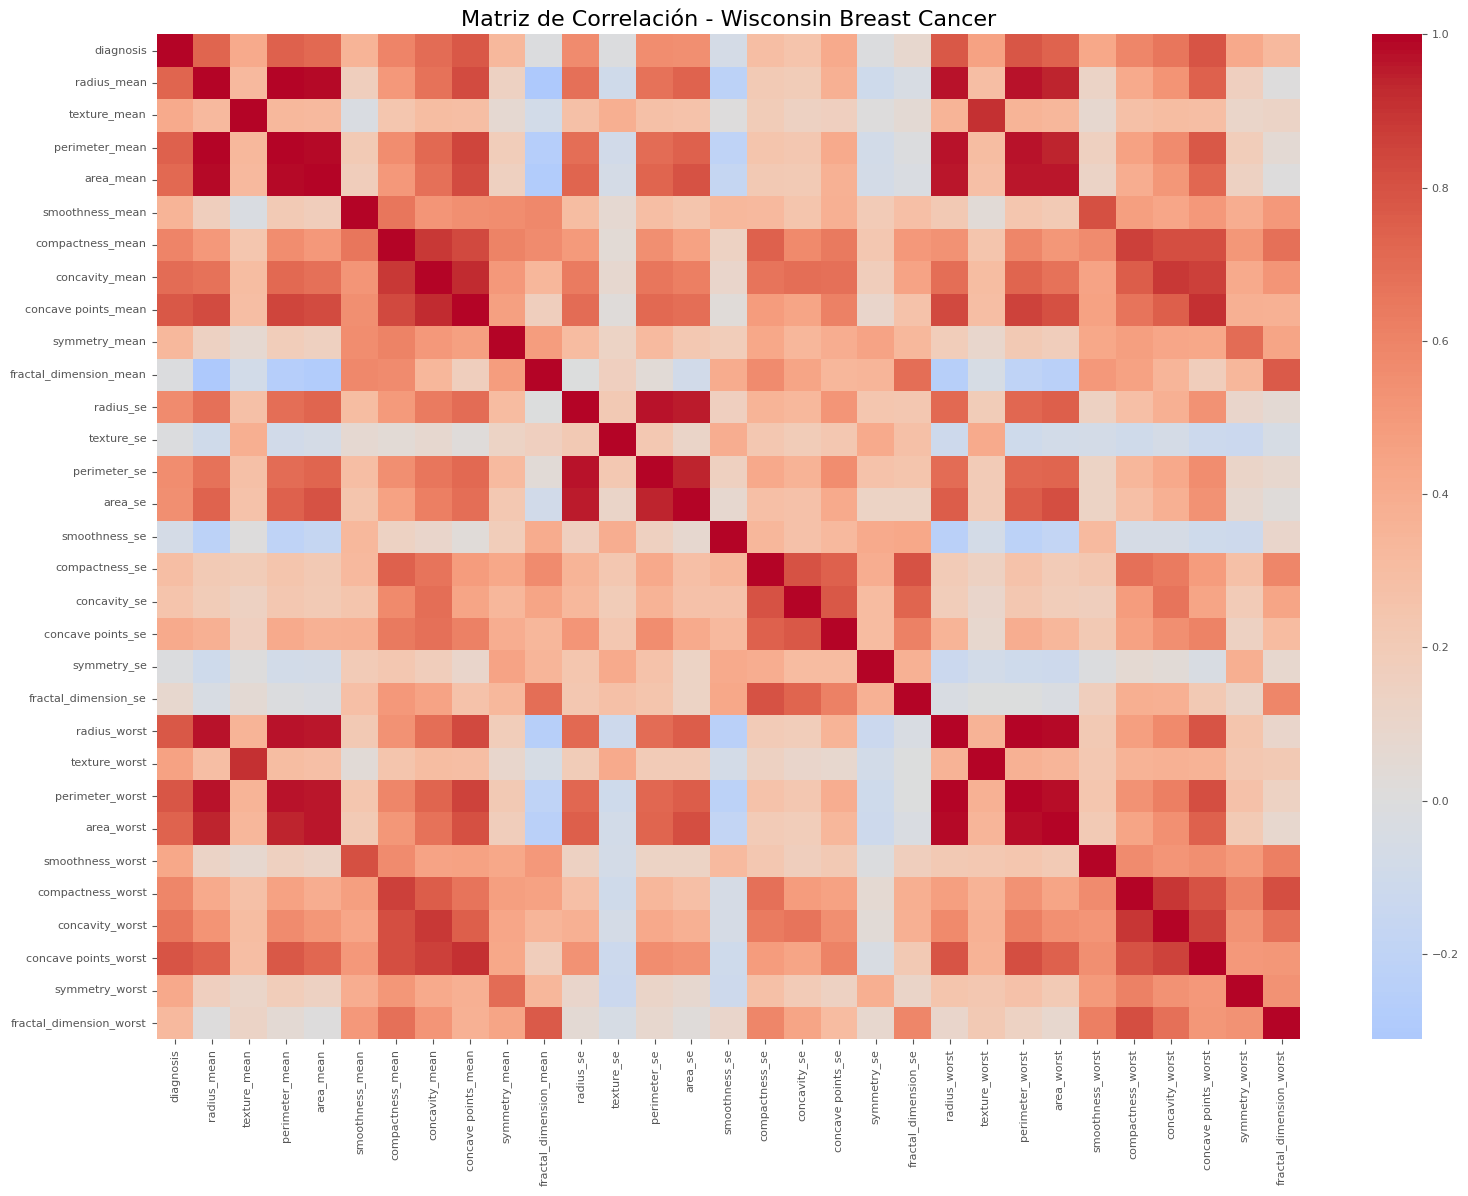

In [28]:
print("Matriz de correlación:")

corr_matrix = df.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación - Wisconsin Breast Cancer', fontsize=16)
plt.tight_layout()
plt.show()

de donde vemos que podriamos eliminar algunas columnas muy correlacionadas, como no son tantas features no sea tan grave.

In [29]:
# Correlación con la variable objetivo
print("Correlación con el diagnóstico:")
target_corr = corr_matrix['diagnosis'].sort_values(ascending=False)
print(target_corr)

Correlación con el diagnóstico:
diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077

In [30]:
top_features = target_corr.index[1:6]  # Top 5 características más correlacionadas
print(f"\nCaracterísticas más importantes: {list(top_features)}")



Características más importantes: ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean']


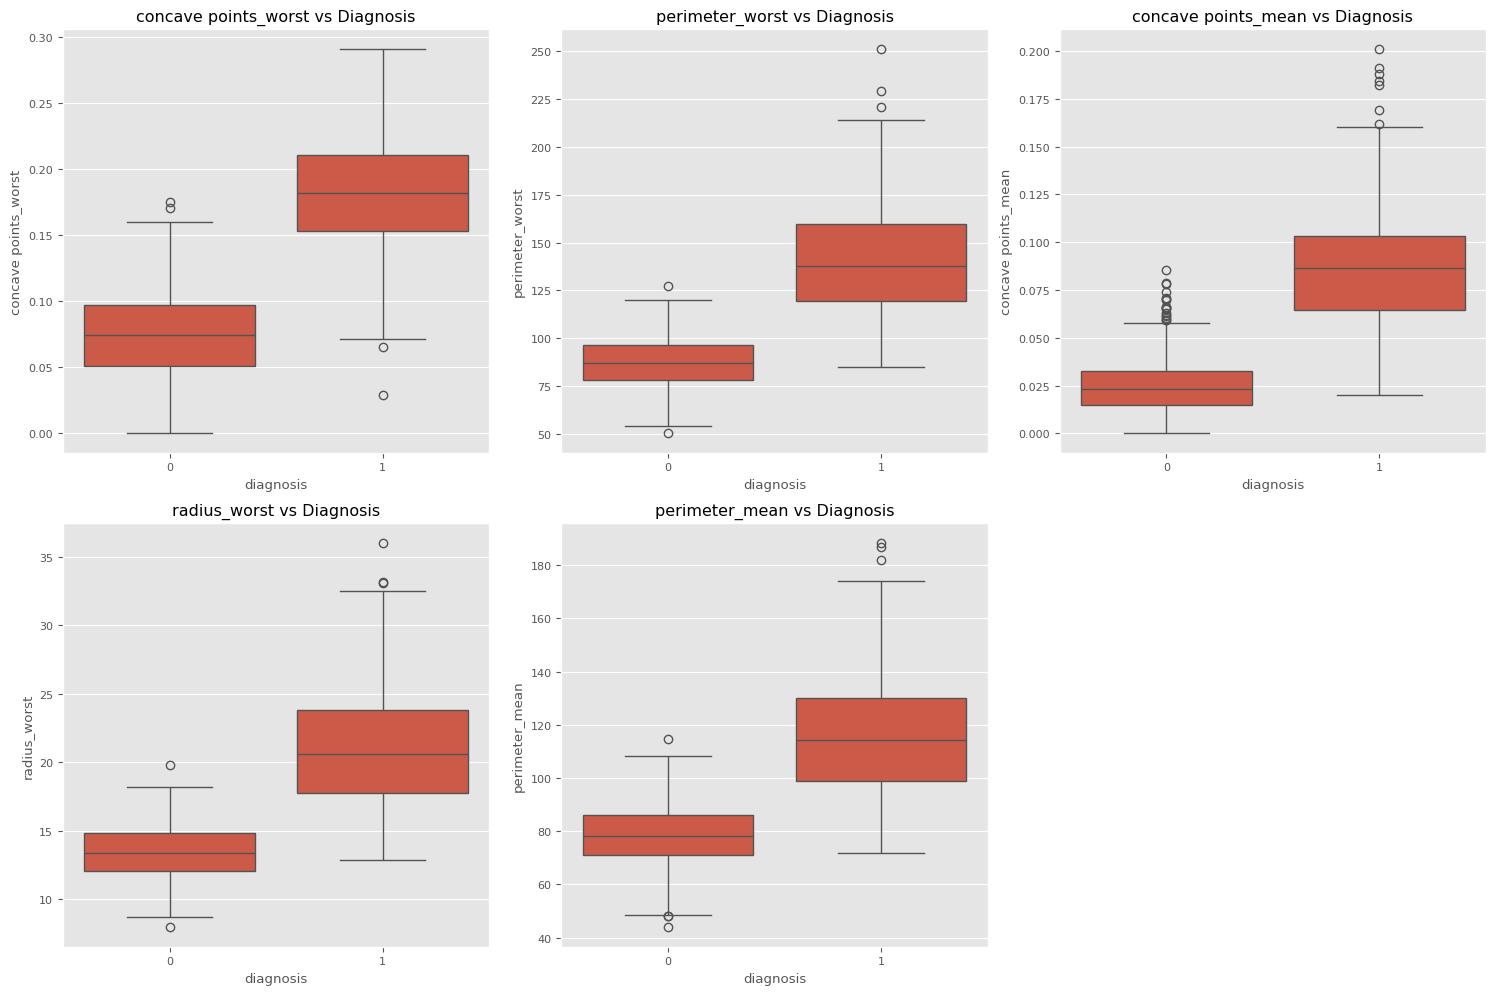

In [31]:
#boxplot de 5 caract. mas correlacionadas con diagnosis
plt.figure(figsize=(15, 10))
for i, feature in enumerate(top_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='diagnosis', y=feature, data=df)
    plt.title(f'{feature} vs Diagnosis')
plt.tight_layout()
plt.show()

veremos si estas estan dentro de las caracter'isticas dadas por los arboles de decision y random forest, ya que por si explicabilidad podrian ser parte de las 5 preguntas iniciales del arbol.

##División Inicial Train/Test
Dividimos el conjunto de datos ANTES de cualquier preprocesamiento para evitar obtener información del conjunto de validacion en el modelo (Data Leakage)




In [76]:
from sklearn.preprocessing import StandardScaler

X = df.drop(['diagnosis'], axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                       test_size=0.30,
                                       #stratify=df['diagnosis'] como ya dividi dataset en X,y ya no
                                       random_state=8,
                                       shuffle=True,
                                       stratify=y )
#se estratifica para mantener proporciones
print("Registros en Train:", len(df_train))
print("Registros en Test:", len(df_test))
print(f"📊 Proporción en entrenamiento: {y_train.value_counts(normalize=True)}")
print(f"📊 Proporción en prueba: {y_test.value_counts(normalize=True)}")



Registros en Train: 398
Registros en Test: 171
📊 Proporción en entrenamiento: diagnosis
0    0.628141
1    0.371859
Name: proportion, dtype: float64
📊 Proporción en prueba: diagnosis
0    0.625731
1    0.374269
Name: proportion, dtype: float64


In [39]:
df_train['diagnosis'].value_counts(normalize=True) #otra forma de ver proporcion de datos en prueba

,proportion
diagnosis,
0,0.628141
1,0.371859


#Preprocesamiento únicamente usando conjunto de entrenamiento

Aunque los árboles de decisión y random forest NO requieren escalado ya que:

*   Basan sus decisiones en umbrales (thresholds), no en distancias

*   Los splits se basan en valores absolutos, no en escalas relativas
*   Son invariantes a transformaciones monótonas


Como queremos usar algoritmos de percetrón, SVM; Regresion logística, Ridge, que SÍ requieren normalizar o estandarizar..preprocesaremos en adelante acorde. Normalización no afectará resultados para árboles de decisión ni random forest aunque usaremos train datafram originales para los modelos que no requieren normalizar.


In [41]:
# Estandarización (usaremos para modelos que lo necesitan)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#visualizamos un poco los datos escalados
print(f"\n Datos escalados - Media: {np.mean(X_train_scaled, axis=0)[:5]}")
print(f" Datos escalados - Std: {np.std(X_train_scaled, axis=0)[:5]}")


📊 Datos escalados - Media: [-2.65560884e-16 -5.98069891e-16  7.54282176e-16  7.69903404e-17
  2.32086823e-16]
📊 Datos escalados - Std: [1. 1. 1. 1. 1.]


#Definicion de modelos y pipelines:



##Arboles de decision

In [43]:
profundidad = None

# Entrenamiento del modelo.
clasificador = DecisionTreeClassifier(max_depth=profundidad,
                                      criterion="entropy",
                                      random_state=0)
clasificador.fit(X_train, y_train)
print("La profundida del árbol es: {}".format(clasificador.get_depth()))

La profundida del árbol es: 5


In [44]:
# Predicción y evaluación sobre el conjunto de entrenamiento.
y_pred_train = clasificador.predict(X_train)
exactitud_train = accuracy_score(y_train, y_pred_train)*100
print("Exactitud conjunto de entrenamiento: {:4.2f}%".format(exactitud_train))

# Predicción y evaluación sobre el conjunto de prueba.
y_pred_test = clasificador.predict(X_test)
exactitud_test = accuracy_score(y_test, y_pred_test)*100
print("Exactitud conjunto de prueba: {:4.2f}%".format(exactitud_test),'\n')

Exactitud conjunto de entrenamiento: 100.00%
Exactitud conjunto de prueba: 94.74% 



Perfecto Overfitting (sobreajuste) cuando dejamos al arbol sin limites, sin prunning, sin regularizacion. Asi que es importante calar con distintas profundidades

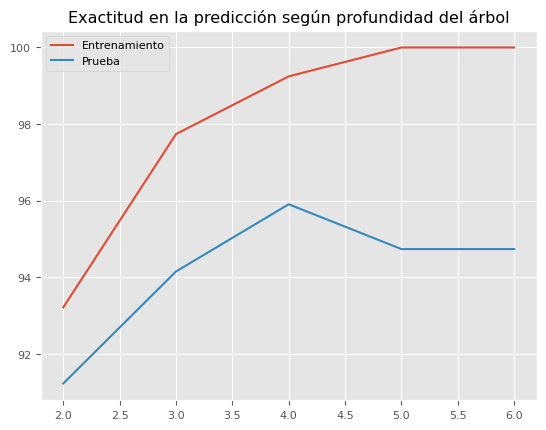

In [61]:
# Entrenamiento y prueba del modelo con distintos niveles de profundidad
clf = {}
y_pred_train = {}
y_pred_test = {}
exactitud_train={}
exactitud_test = {}

for p in range(2,7):
    # Entrenamiento del modelo
    clf[p] = DecisionTreeClassifier(max_depth = p,
                               criterion = "entropy",
                               random_state = 0).fit(X_train, y_train)

    # Predicción y evaluación sobre el conjunto de entrenamiento
    y_pred_train[p] = clf[p].predict(X_train)
    exactitud_train[p] = accuracy_score(y_train, y_pred_train[p])*100

    # Predicción y evaluación sobre el conjunto de prueba
    y_pred_test[p] = clf[p].predict(X_test)
    exactitud_test[p] = accuracy_score(y_test, y_pred_test[p])*100

exactitud_df = pd.DataFrame( {'Entrenamiento':exactitud_train,
                           'Prueba': exactitud_test})

exactitud_df.plot.line(
    title ='Exactitud en la predicción según profundidad del árbol')
plt.show()

In [62]:
exactitud_df

,Entrenamiento,Prueba
2,93.216080,91.228070
3,97.738693,94.152047
4,99.246231,95.906433
5,100.000000,94.736842
6,100.000000,94.736842


In [63]:
profundidad_optima = exactitud_df['Prueba'].idxmax()
profundidad_optima

np.int64(4)

de lo que vemos que la profundidad para un arbol de decision de 4 preguntas es optimo

In [64]:
model_tree = clf[profundidad_optima]

##visualizando arbol de decision

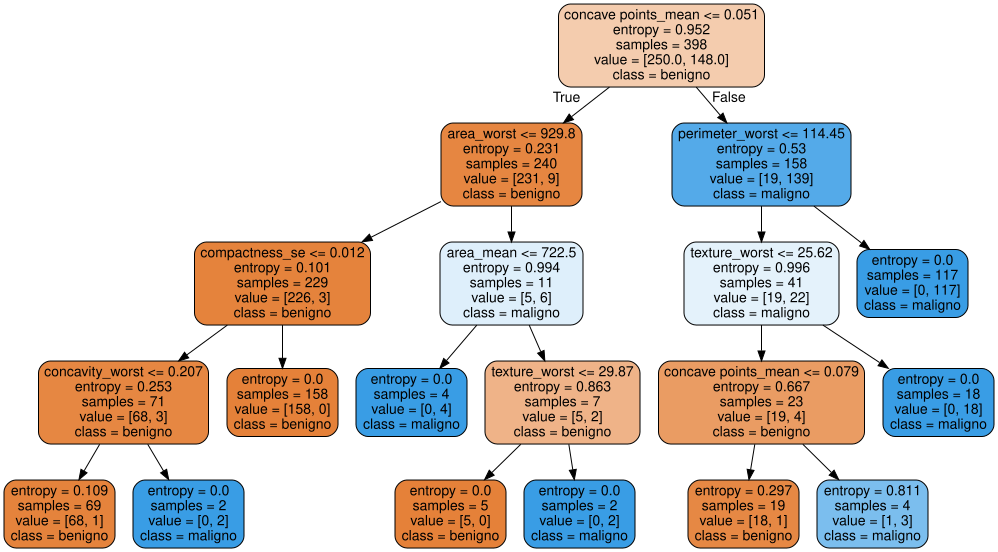

In [66]:
# Exportar el árbol como archivo.dot

dot_data = export_graphviz(model_tree, feature_names=X_train.columns,
                           class_names=['benigno','maligno'],
                           max_depth = 4,
                           rounded = True,
                           filled = True,
                           )

graph =  graphviz.Source(dot_data, format='png')

graph.render('arbol_decision')              # guarda el archivo .dot y la gráfica png
graph

Es bueno recordar y visualizar de un árbol de decisión la interpretabilidad y feature selection de las caracteristicas con el diagrama de arriba, incluso podemos subir umbral de entropia para ser mas minuciosos.

In [ ]:
!pip install dtreeviz
viz_tree = dtreeviz.model(model_tree, X_train, y_train,
                target_name='diagnosis',
                feature_names=X_train.columns,
                class_names=['benigno','maligno'])

v = viz_tree.view(fontname="monospace", scale=1.2)     # render para guardar en formato
v.save("viz_tree.svg")
v

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 2.2 MB/s eta 0:00:00


##Importancia de las variables, feature selection


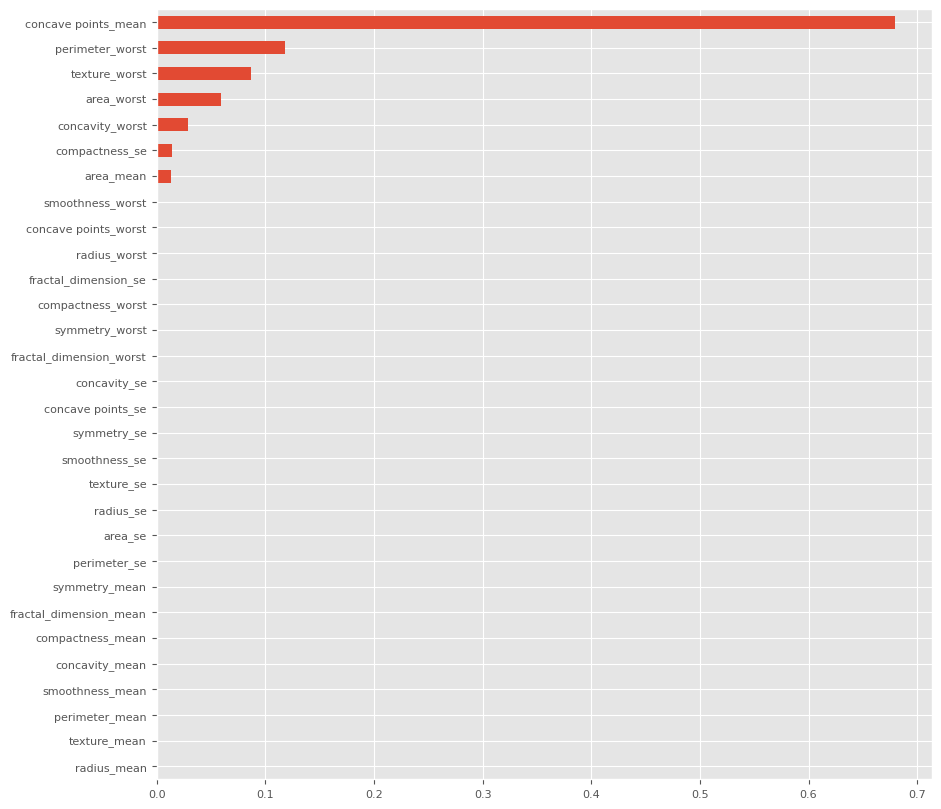

In [78]:
importancia = pd.Series(model_tree.feature_importances_,
                    index=X_train.columns.values)

importancia.sort_values().plot(kind = 'barh',figsize=(10, 10))
plt.show()

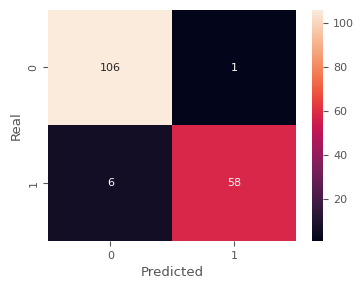

In [79]:
#Matriz de confusión
data = {'y_Real':y_test, 'y_Prediccion':model_tree.predict(X_test)}

df = pd.DataFrame(data)
confusion_matrix = pd.crosstab(df['y_Real'], df['y_Prediccion'],
                               rownames=['Real'], colnames=['Predicted'])
fig, ax = plt.subplots(figsize=(4,3))
sns.heatmap(confusion_matrix, annot=True, fmt='g')
plt.show()

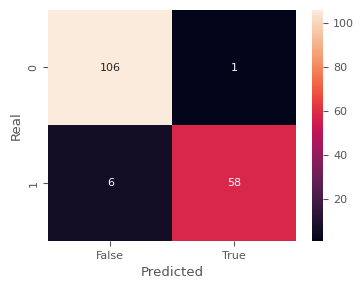

In [84]:
umbral = 0.10 # por arriba del cual se clasificaría como clase 1
prediccion_test = np.where( model_tree.predict_proba(X_test)[:, 1] > umbral, True, False)
data = {'y_Real':  y_test,
        'y_Prediccion': prediccion_test
        }

evaluacion_df = pd.DataFrame(data)
confusion_matrix = pd.crosstab(evaluacion_df['y_Real'], evaluacion_df['y_Prediccion'], rownames=['Real'], colnames=['Predicted'])
fig, ax = plt.subplots(figsize=(4,3))
sns.heatmap(confusion_matrix, annot=True, fmt='g')
plt.show()

Curva Roc para arbol de decision

In [86]:
from sklearn.metrics import RocCurveDisplay

KeyError: 7

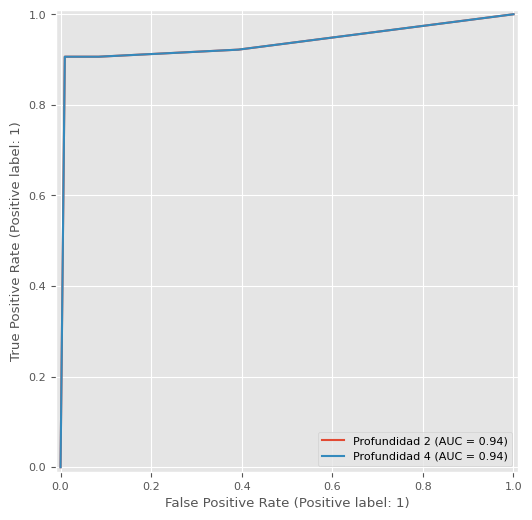

In [93]:

fig, ax = plt.subplots(figsize=(6, 6))

RocCurveDisplay.from_estimator(model_tree, X_test, y_test, name='Profundidad 2', ax=ax)

RocCurveDisplay.from_estimator(clf[4], X_test, y_test, name='Profundidad 4', ax=ax)

RocCurveDisplay.from_estimator(clf[7], X_test, y_test, name='Profundidad 7', ax=ax)

ax.set_title('Curvas ROC para Arboles de Decisión con distintas profundidades')

plt.show()

Podemos adoptar estrategias de regularizacion usando randomForestClassifier por ejemplo.

In [81]:
#RandomForest Classifier con 100 arboles para regularizar
clf_rf = RandomForestClassifier(n_estimators=100,  random_state =0,
                                criterion='entropy').fit(X_train, y_train)

y_train_pred = clf_rf.predict(X_train)
y_pred = clf_rf.predict(X_test)
print("Exactitud del modelo Bosque Aleatorio en el conjunto de entrenamiento: {:4.2f}%".format(accuracy_score(y_train, y_train_pred )*100))
print("Exactitud del modelo Bosque Aleatorio en el conjunto de prueba: {:4.2f}%".format(accuracy_score(y_test, y_pred)*100))

Exactitud del modelo Bosque Aleatorio en el conjunto de entrenamiento: 100.00%
Exactitud del modelo Bosque Aleatorio en el conjunto de prueba: 96.49%


<Axes: >

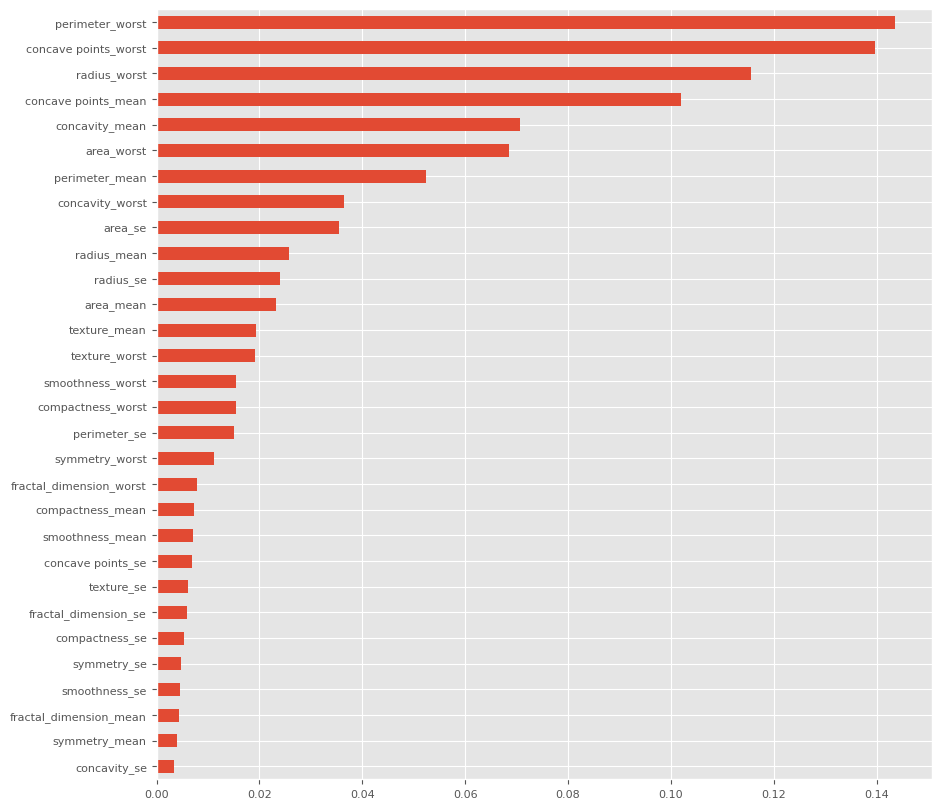

In [82]:
#importancia

importances = clf_rf.feature_importances_
weights = pd.Series(importances,
                    index=X.columns.values)
weights.sort_values().plot(kind = 'barh',figsize=(10, 10))

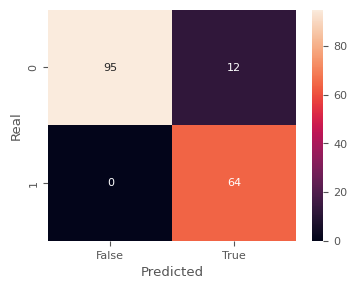

In [83]:
umbral = 0.10 # por arriba del cual se clasificaría como clase 1
prediccion_test = np.where( clf_rf.predict_proba(X_test)[:, 1] > umbral, True, False)
data = {'y_Real':  y_test,
        'y_Prediccion': prediccion_test
        }

evaluacion_df = pd.DataFrame(data)
confusion_matrix = pd.crosstab(evaluacion_df['y_Real'], evaluacion_df['y_Prediccion'], rownames=['Real'], colnames=['Predicted'])
fig, ax = plt.subplots(figsize=(4,3))
sns.heatmap(confusion_matrix, annot=True, fmt='g')
plt.show()

para objetivo del notebook provemos calar modelos de Perceptron, SVM, Regresion logistica y Ridge.

In [48]:
#perceptron sin margen:
model = Perceptron(max_iter=1000, random_state=0, verbose=False).fit(X_train, y_train)

print("Iterations: ", model.n_iter_)
# Es muy importante comparar el error en el entrenamiento contra el error de generalización
print("Exactitud conjunto entrenamiento: %.2f%%" % (model.score(X_train, y_train)*100))
print("Exactitud conjunto prueba: %.2f%%" % (model.score(X_test, y_test)*100))

Iterations:  19
Exactitud conjunto entrenamiento: 91.71%
Exactitud conjunto prueba: 89.47%


Viendo el tipo de errores que tenemos con la matriz de confusion:

In [53]:
y_predict = model.predict(X_test)  # Predice la etiqueta de cada imagen en X_test
y_predict[:20]

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0])

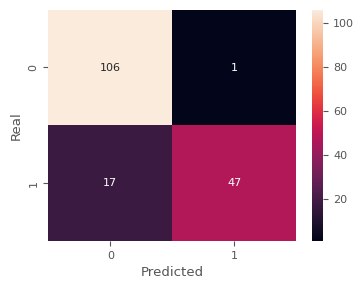

In [54]:

def matriz_confusion(y_test, y_predict):
    df = pd.DataFrame({
        'Real': y_test,
        'Predicted': y_predict
    })
    # Matriz de confusión
    confusion_matrix = pd.crosstab(df['Real'],df['Predicted']
                               )
    fig, ax = plt.subplots(figsize=(4, 3))  # Tamaño de la figura
    _ = sns.heatmap(confusion_matrix, annot=True, fmt='g',  ax=ax)

matriz_confusion(y_test, y_predict)

In [59]:
#perceptron usando margen para quitar overfitting que era de esperar...
model_2 = Perceptron(max_iter=15,  random_state=0, verbose=False,
                    penalty='l2', alpha=7e-9)
model_2.fit(X_train,y_train)
print("Iterations: ", model_2.n_iter_)
print("Exactitud conjunto entrenamiento: %.2f%%" % (model_2.score(  X_train, y_train)*100.0))
print("Exactitud conjunto prueba: %.2f%%" % (model_2.score(X_test, y_test)*100.0))

Iterations:  15
Exactitud conjunto entrenamiento: 91.21%
Exactitud conjunto prueba: 88.89%


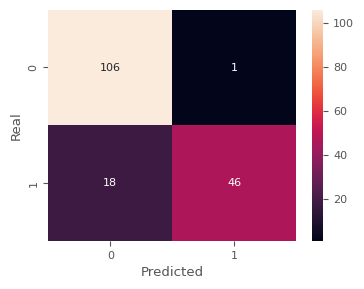

In [60]:
y_predict_2 = model_2.predict(X_test)
matriz_confusion(y_test, y_predict_2)

Hicimos primero una prueba con arboles de decision usando entropia por su concepto en el modelo matematico midiendo informacion acerca de cada caracteristica para hacer mejor prediccion, solo para tener idea de que en efecto, quizas la cantidad de caracteristicas mas relevantes sean solo 5.


##Pipelines Esto queda pendiente para los siguientes dias a partir del 15 de febrero 2026

En adelante veremos pipeline probando distintas profundidades para arboles de decision ya con medidas de regularizacion para evitar sobreajuste.

In [42]:
# Definición de modelos con sus parámetros
# Modelos que requieren estandarización de los rangos de datos
modelos_escalados = {
    'Perceptron': {
        'model': Perceptron(random_state=42, max_iter=1000, tol=1e-3),
        'params': {
            'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0],
            'model__penalty': ['l2', 'l1', 'elasticnet']
        }
    },

    'SVM': {
        'model': SVC(random_state=42, probability=True),
        'params': {
            'model__C': [0.1, 1, 10, 100],
            'model__kernel': ['linear', 'rbf', 'poly'],
            'model__gamma': ['scale', 'auto', 0.1, 1]
        }
    },

    'Regresión Logística': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
            'model__penalty': ['l2'], #Ridge es L2
            'model__solver': ['lbfgs', 'liblinear']
        }
    },

    'Ridge Classifier': {
        'model': RidgeClassifier(random_state=42),
        'params': {
            'model__alpha': [0.1, 1.0, 10.0, 100.0],
            'model__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']
        }
    }
}

# Modelos que NO requieren estandarización
modelos_sin_escalar = {
    'Árbol de Decisión': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'criterion': ['gini', 'entropy']
        }
    },

    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    }
}


# Crear pipelines para modelos que necesitan escalado
pipelines_escalados = {}
for nombre, config in modelos_escalados.items():
    pipelines_escalados[nombre] = Pipeline([
        ('scaler', StandardScaler()),
        ('model', config['model'])
    ])

print("📋 Modelos definidos:")
print("🔹 Modelos con escalado:", list(pipelines_escalados.keys()))
print("🔹 Modelos sin escalado:", list(modelos_sin_escalar.keys()))


📋 Modelos definidos:
🔹 Modelos con escalado: ['Perceptron', 'Regresión Logística', 'Ridge Classifier', 'SVM']
🔹 Modelos sin escalado: ['Árbol de Decisión', 'Random Forest']


# Curva ROC-AUC para evaluar desempeno de modelos

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# Initialize a dictionary to store AUC - ROC scores
roc_auc_scores = {}

# Plot the ROC curves
plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Predict the probabilities
    y_probs = model.predict_proba(X_test)[:, 1]

    # Calculate the AUC - ROC score
    roc_auc = roc_auc_score(y_test, y_probs)
    roc_auc_scores[name] = roc_auc

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_probs)

    # Plot ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Customize the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()

# Print the AUC - ROC scores for each model
for name, score in roc_auc_scores.items():
    print(f'{name}: AUC - ROC = {score:.2f}')

# Fuentes y agradecimientos:

Visualizaci'on de datos:
https://www.kaggle.com/code/kanncaa1/feature-selection-and-data-visualization


Para visualizacion de arboles de decision:
https://www.kaggle.com/code/anshtanwar/visualize-decision-trees-dtreeviz

Guia de clasificador de cancer de mama (tiene pipiline interesante para varios modelos con CV cross-validation que sera util en siguientes modulos):
https://www.kaggle.com/code/buddhiniw/breast-cancer-prediction

Clasificador de Churn con arboles de decisi'on y random forest:
https://github.com/AnIsAsPe/ClasificadorClientesTelecom/blob/master/Notebooks/Churn_Telecom.ipynb
